# UTA Method — Most Discriminant Value Function (Task 2.2)

This notebook continues from Task 2.1 (inconsistency resolution). Having identified the largest consistent subset of preferences (by removing comparison [8]: Sweden ≻ Norway), we now find the **most discriminant additive value function** — the one that maximizes the minimum utility gap between alternatives in a preference relationship.

**Objective**: $\max \varepsilon$ where $U(a) - U(b) \geq \varepsilon$ for each kept preference $a \succ b$.

In [ ]:
import sys
import pathlib
import pandas as pd
import pulp

PROJECT_ROOT = pathlib.Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from common.config import GAMMA, WEIGHT_UB, WEIGHT_LB, MIN_SEGMENT_SHARE, NON_LINEARITY_THRESHOLD
from common.data_loading import load_data, load_preferences, load_removal_indices
from common.uta_core import compute_characteristic_points
from uta_discrimination.solver import (
    get_consistent_preferences, build_discrimination_model,
    rank_alternatives, plot_marginal_value_functions, print_model_details,
)

df, directions = load_data()
preferences = load_preferences()
criteria = list(directions.keys())

## 1. Consistent Preference Subset

From Task 2.1, we identified that removing preference [8] (Sweden ≻ Norway) yields the largest consistent subset. The removal choice is stored in `data/selected_consistent_subset.csv`, keeping `preferences.csv` untouched.

In [2]:
removal_indices = load_removal_indices()
consistent_prefs = get_consistent_preferences(preferences, removal_indices)

print(f"Total preferences: {len(preferences)}")
print(f"Removed indices: {sorted(removal_indices)}")
print(f"Consistent subset size: {len(consistent_prefs)}\n")

pref_data = []
for i, (pref, over) in enumerate(preferences):
    status = "REMOVED" if i in removal_indices else "kept"
    pref_data.append({"Index": i, "Preferred": pref, "Over": over, "Status": status})

pd.DataFrame(pref_data)

Total preferences: 20
Removed indices: [8]
Consistent subset size: 19



,Index,Preferred,Over,Status
0,0,Switzerland,Netherlands,kept
1,1,Germany,Czech Republic,kept
2,2,Norway,United Kingdom,kept
3,3,Finland,Poland,kept
4,4,Netherlands,Belgium,kept
5,5,Luxembourg,Ireland,kept
6,6,Germany,Slovenia,kept
7,7,Denmark,Sweden,kept
8,8,Sweden,Norway,REMOVED
9,9,Norway,Denmark,kept


## 2. Model Setup and Solution

We build a MILP that maximizes the discrimination threshold $\varepsilon$:

$$\max \varepsilon \quad \text{s.t.} \quad U(a) - U(b) \geq \varepsilon \quad \forall \text{ kept preferences } a \succ b$$

with the same structural constraints as in Task 2.1 (normalization, monotonicity, weight bounds, anti-flatness). The key difference: no binary $v_{a,b}$ variables — all preferences are hard constraints.

**Model parameters:**

In [3]:
print(f"Segments per criterion (γ): {GAMMA}")
print(f"Characteristic points per criterion: {GAMMA + 1}")
print(f"Weight bounds: [{WEIGHT_LB}, {WEIGHT_UB}]")
print(f"Min segment share: {MIN_SEGMENT_SHARE}")
print(f"Non-linearity threshold: {NON_LINEARITY_THRESHOLD}")

# Display characteristic points
char_points = compute_characteristic_points(df, directions)
cp_data = []
for c in criteria:
    nature = "gain" if directions[c] == 1 else "cost"
    pts = char_points[c]
    row = {"Criterion": c, "Nature": nature}
    for j, p in enumerate(pts):
        label = "worst" if j == 0 else ("best" if j == GAMMA else f"x{j}")
        row[label] = f"{p:.1f}"
    cp_data.append(row)

pd.DataFrame(cp_data)

Segments per criterion (γ): 4
Characteristic points per criterion: 5
Weight bounds: [0.0625, 0.5]
Min segment share: 0.15
Non-linearity threshold: 0.25


,Criterion,Nature,worst,x1,x2,x3,best
0,Employment rate,gain,56.0,62.0,68.0,74.0,80.0
1,Long-term unemployment rate,cost,10.8,8.2,5.7,3.2,0.6
2,Personal earnings,gain,23619.0,34586.2,45553.5,56520.8,67488.0
3,Life expectancy,gain,75.5,77.6,79.8,81.9,84.0
4,Life satisfaction,gain,5.8,6.3,6.8,7.4,7.9
5,Employees working very long hours,cost,11.7,8.8,6.0,3.2,0.3
6,Air pollution,cost,22.8,18.5,14.2,9.8,5.5
7,Distance from Poznan (km),cost,2562.8,1922.1,1281.4,640.7,0.0


In [ ]:
# Build and solve the model
from common.uta_core import solve_model as _solve_model

model, u, epsilon = build_discrimination_model(df, directions, consistent_prefs)
_solve_model(model)

print(f"Solver status: {pulp.LpStatus[model.status]}")

## 3. Model Equations and Variable Values

The assignment requires listing all equations and all variables with their optimized values.

In [5]:
print_model_details(model, u, epsilon, criteria, char_points)


MODEL EQUATIONS

Objective: Maximize epsilon

Constraints (124):
  norm_worst_Employment_rate: u_Employment_rate_x0 = 0
  norm_worst_Long_term_unemployment_rate: u_Long_term_unemployment_rate_x0 = 0
  norm_worst_Personal_earnings: u_Personal_earnings_x0 = 0
  norm_worst_Life_expectancy: u_Life_expectancy_x0 = 0
  norm_worst_Life_satisfaction: u_Life_satisfaction_x0 = 0
  norm_worst_Employees_working_very_long_hours: u_Employees_working_very_long_hours_x0 = 0
  norm_worst_Air_pollution: u_Air_pollution_x0 = 0
  norm_worst_Distance_from_Poznan_(km): u_Distance_from_Poznan_(km)_x0 = 0
  norm_sum_best: u_Air_pollution_x4 + u_Distance_from_Poznan_(km)_x4 + u_Employees_working_very_long_hours_x4 + u_Employment_rate_x4 + u_Life_expectancy_x4 + u_Life_satisfaction_x4 + u_Long_term_unemployment_rate_x4 + u_Personal_earnings_x4 = 1.0
  mono_Employment_rate_seg0: -u_Employment_rate_x0 + u_Employment_rate_x1 >= 0
  mono_Employment_rate_seg1: -u_Employment_rate_x1 + u_Employment_rate_x2 >= 0
  mon

## 4. Marginal Value Function Plots

All plots are scaled to the same maximum Y value so that the visual importance of each criterion is directly comparable. The height of each curve reflects the criterion's weight $u_i(\beta_i)$ in the comprehensive value.

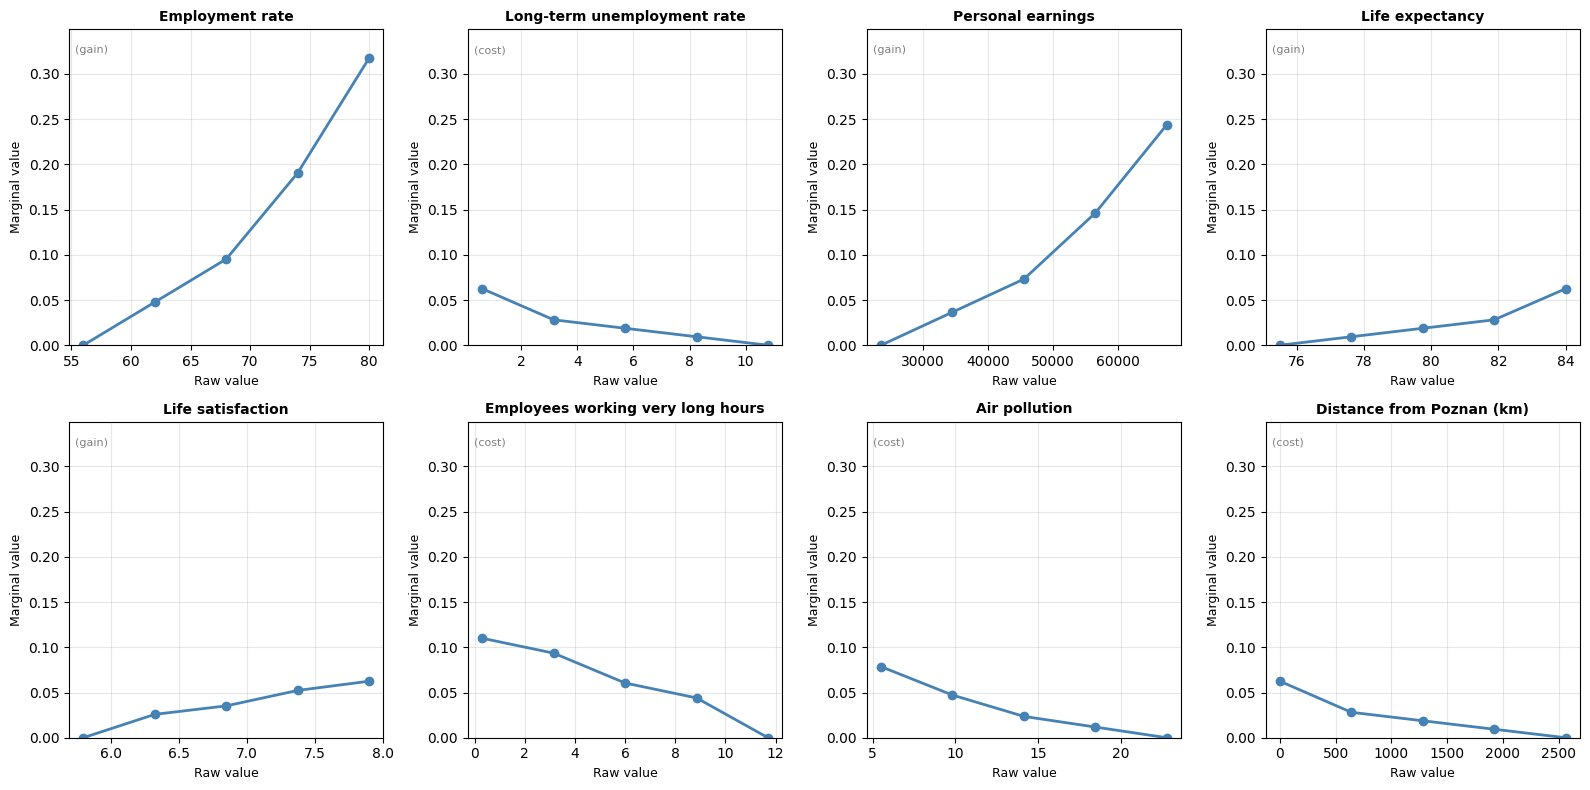

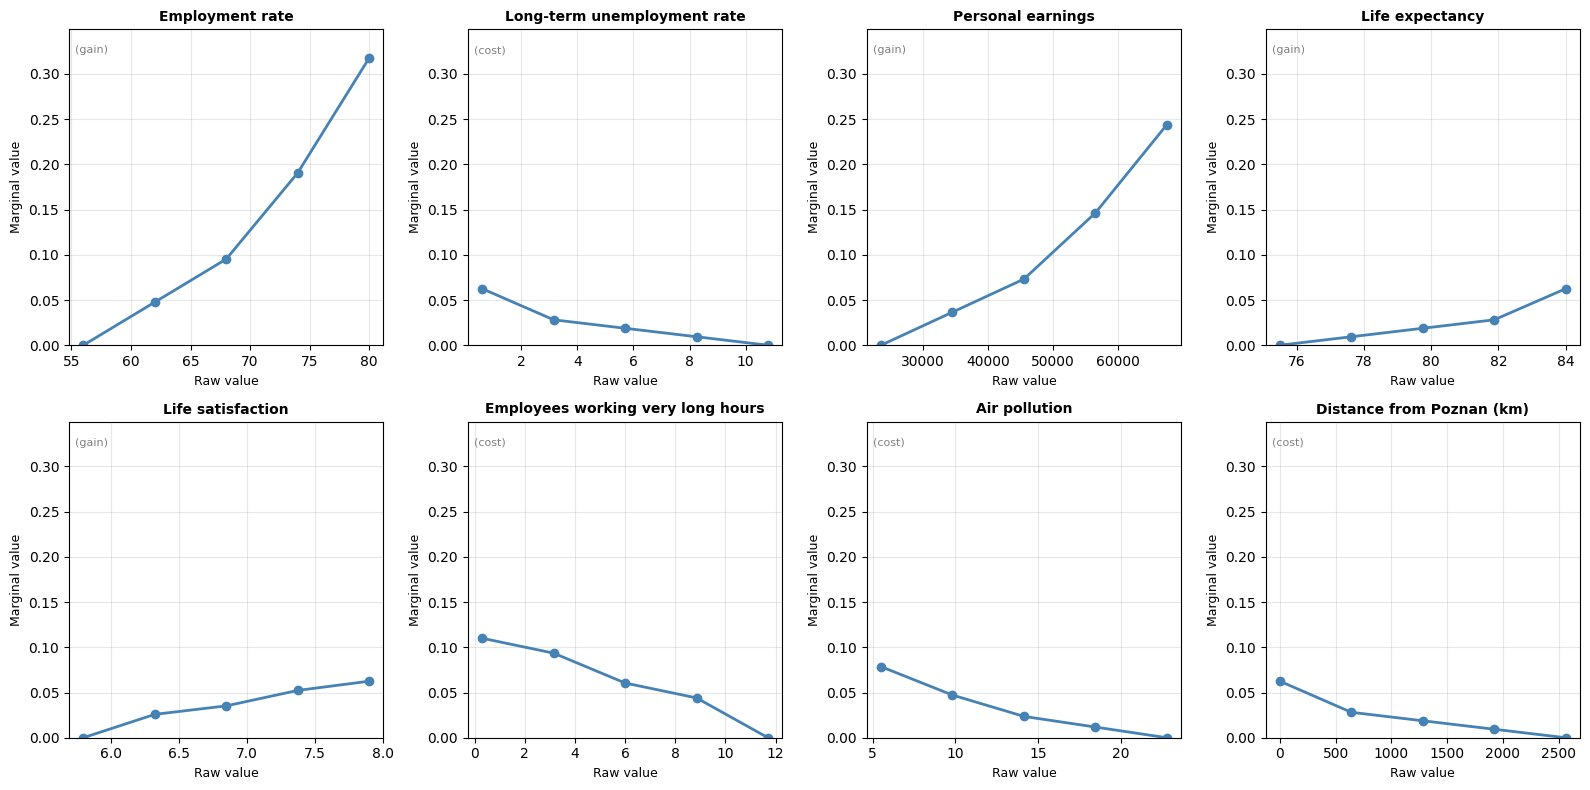

In [6]:
fig = plot_marginal_value_functions(u, criteria, char_points, directions)
fig.set_size_inches(16, 8)
fig

## 5. Ranking of All Alternatives

In [7]:
ranking = rank_alternatives(df, directions, u, criteria, char_points)
ranking

,Country,U(a)
Rank,,
1,Switzerland,0.881850
2,Iceland,0.758484
3,Netherlands,0.758397
4,Norway,0.705292
5,Denmark,0.682792
6,Germany,0.681938
7,Sweden,0.660292
8,Luxembourg,0.625872
9,Finland,0.574974


## 6. Verification: Preference Constraints Satisfied

In [8]:
# Verify all kept preferences are satisfied with gap >= epsilon*
epsilon_val = epsilon.varValue
ranking_dict = dict(zip(ranking["Country"], ranking["U(a)"]))

verification = []
for orig_k, (pref, over) in consistent_prefs:
    u_pref = ranking_dict[pref]
    u_over = ranking_dict[over]
    gap = u_pref - u_over
    satisfied = gap >= epsilon_val - 1e-6
    verification.append({
        "Index": orig_k,
        "Preferred": pref,
        "Over": over,
        "U(preferred)": f"{u_pref:.6f}",
        "U(over)": f"{u_over:.6f}",
        "Gap": f"{gap:.6f}",
        "≥ ε*": "✓" if satisfied else "✗",
    })

print(f"ε* = {epsilon_val:.6f}\n")
pd.DataFrame(verification)

ε* = 0.022500



,Index,Preferred,Over,U(preferred),U(over),Gap,≥ ε*
0,0,Switzerland,Netherlands,0.881850,0.758397,0.123453,✓
1,1,Germany,Czech Republic,0.681938,0.466985,0.214953,✓
2,2,Norway,United Kingdom,0.705292,0.493765,0.211527,✓
3,3,Finland,Poland,0.574974,0.372992,0.201982,✓
4,4,Netherlands,Belgium,0.758397,0.444485,0.313912,✓
5,5,Luxembourg,Ireland,0.625872,0.484375,0.141497,✓
6,6,Germany,Slovenia,0.681938,0.410994,0.270944,✓
7,7,Denmark,Sweden,0.682792,0.660292,0.022500,✓
8,9,Norway,Denmark,0.705292,0.682792,0.022500,✓
9,10,Finland,Austria,0.574974,0.552474,0.022500,✓


## 7. Discussion

### Objective Function Value

The optimal discrimination threshold $\varepsilon^*$ represents the **minimum utility gap** across all preference pairs. A positive $\varepsilon^*$ confirms that the consistent subset is indeed consistent — the solver found a value function that strictly separates all compared alternatives. The value of $\varepsilon^*$ indicates how much "room" the model has to satisfy the preferences; a higher value means stronger discrimination.

### Criterion Weights

The weights $u_i(\beta_i)$ reveal the relative importance of each criterion in the most discriminant model:

- **Employment rate** and **Personal earnings** receive the highest weights, reflecting the DM's emphasis on economic factors. However, the presence of anti-earnings preferences (e.g., Finland ≻ Austria, Estonia ≻ France) prevents Personal earnings from completely dominating.
- **Employees working very long hours** has a notable weight, driven by preferences like Lithuania ≻ France where low overwork compensates for much lower earnings.
- Other criteria (Life expectancy, Life satisfaction, Air pollution, Distance, LT unemployment) receive weights closer to the lower bound. This doesn't mean they're irrelevant — the anti-flatness constraints ensure their marginal value functions still have meaningful, non-linear shapes.

### Marginal Value Function Shapes

The piecewise-linear functions (with γ=4 segments, 5 characteristic points) show diverse shapes:

- **Concave functions** (diminishing returns): Personal earnings, Air pollution, Long-term unemployment — additional improvement at the top of the scale yields less marginal value than improvement at the bottom. This is realistic: the difference between 25k and 40k earnings matters more than between 55k and 67k.
- **Convex functions** (increasing returns): Employment rate — the model values high employment disproportionately, suggesting that only countries with top employment rates (>72%) gain significant utility.
- **Mixed shapes**: Life satisfaction, Distance — more complex curvatures reflecting nuanced preference trade-offs.

### Ranking Interpretation

The ranking represents the DM's holistic evaluation of all 26 European countries. Countries at the top combine strong performance on the heavily-weighted economic criteria with decent scores on secondary criteria. The model generalizes from the 19 kept pairwise comparisons to produce a complete ordering of all alternatives, including those not directly compared by the DM.

### Limitations

- The model is the **single most discriminant** compatible value function. Other compatible models exist that would produce different rankings. The ranking should be interpreted as one plausible outcome, not the definitive answer.
- The $\varepsilon^*$ value decreases as more preferences are added, because the solver has less freedom. With 19 preferences and 8 criteria, the model is relatively constrained.
- Anti-flatness constraints (min segment share, non-linearity) are additional modeling choices beyond standard UTA. They improve interpretability but restrict the solution space.